# 1 Import Libraries

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
#from IPython.display import HTML, display

# 2 Load Dataset

In [139]:
# 1. Load data
df = pd.read_csv('Plant_1_Generation_Data.csv')
df

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [140]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [141]:
gen1 = pd.read_csv("Plant_1_Generation_Data.csv")
weather1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

gen2 = pd.read_csv("Plant_2_Generation_Data.csv")
weather2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

print(gen1.head())
print(weather1.head())

print(gen2.head())
print(weather2.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135

# 3 Merge Dataset

In [142]:
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])

gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'])
weather2['DATE_TIME'] = pd.to_datetime(weather2['DATE_TIME'])

plant1 = pd.merge(gen1, weather1, on="DATE_TIME")
plant2 = pd.merge(gen2, weather2, on="DATE_TIME")

data = pd.concat([plant1, plant2])

C:\Users\aswan\AppData\Local\Temp\ipykernel_6488\2953119160.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'])


In [143]:
data

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
67693,2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.0,520758.0,4136001,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67694,2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.0,121131356.0,4136001,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67695,2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.0,2427691.0,4136001,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0
67696,2020-06-17 23:45:00,4136001,xMbIugepa2P7lBB,0.0,0.0,4218.0,106896394.0,4136001,iq8k7ZNt4Mwm3w0,23.202871,22.535908,0.0


In [144]:
data.isnull().sum()

DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

# 4 Preprocessing

In [145]:
# Fix date format properly
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], dayfirst=True)
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])

gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'])
weather2['DATE_TIME'] = pd.to_datetime(weather2['DATE_TIME'])

# Merge
plant1 = pd.merge(gen1, weather1, on="DATE_TIME")
plant2 = pd.merge(gen2, weather2, on="DATE_TIME")

data = pd.concat([plant1, plant2])

# Clean
data = data.ffill()
data = data.drop_duplicates()

# 5 Features

In [146]:
data['hour'] = data['DATE_TIME'].dt.hour
data['day'] = data['DATE_TIME'].dt.day
data['month'] = data['DATE_TIME'].dt.month

features = ['IRRADIATION','AMBIENT_TEMPERATURE',
            'MODULE_TEMPERATURE','hour','day','month']

X = data[features]
y = data['AC_POWER']

# 6 Scaling

In [178]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

# 7 Data Exploration (EDA)


C:\Users\aswan\AppData\Local\Temp\ipykernel_6488\1435674038.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])


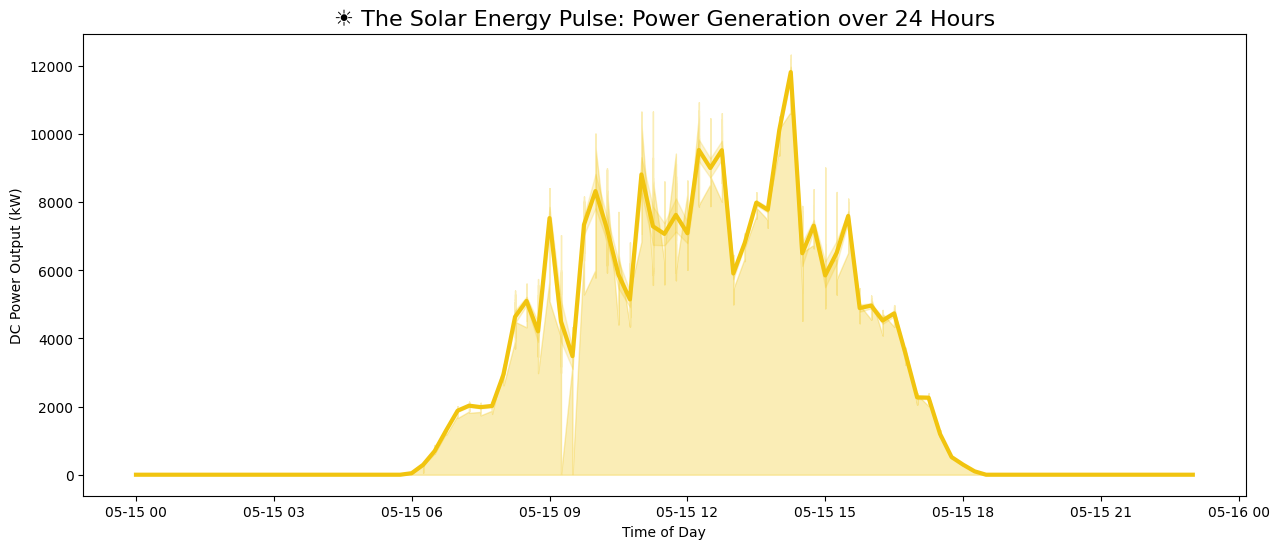

In [148]:
# 1 Visualizing a single day to show the "Sun Curve"
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
single_day = df[df['DATE_TIME'].dt.date == df['DATE_TIME'].dt.date.iloc[0]]

plt.figure(figsize=(15, 6))
sns.lineplot(data=single_day, x='DATE_TIME', y='DC_POWER', color='#f1c40f', linewidth=3)
plt.fill_between(single_day['DATE_TIME'], single_day['DC_POWER'], color='#f1c40f', alpha=0.3)
plt.title("☀️ The Solar Energy Pulse: Power Generation over 24 Hours", fontsize=16)
plt.ylabel("DC Power Output (kW)")
plt.xlabel("Time of Day")
plt.show()

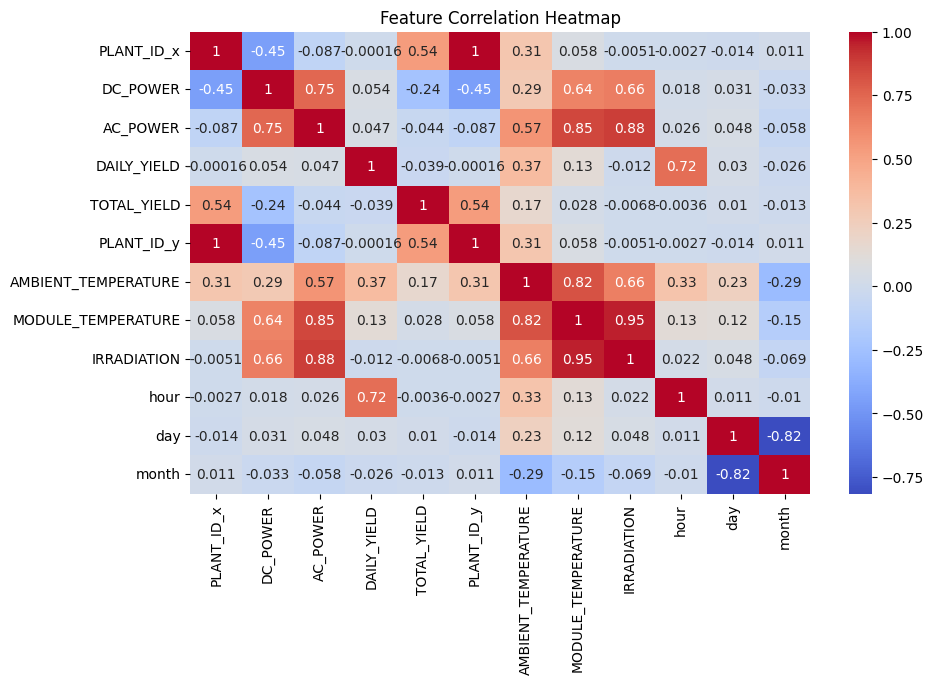

In [149]:
# 2 Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

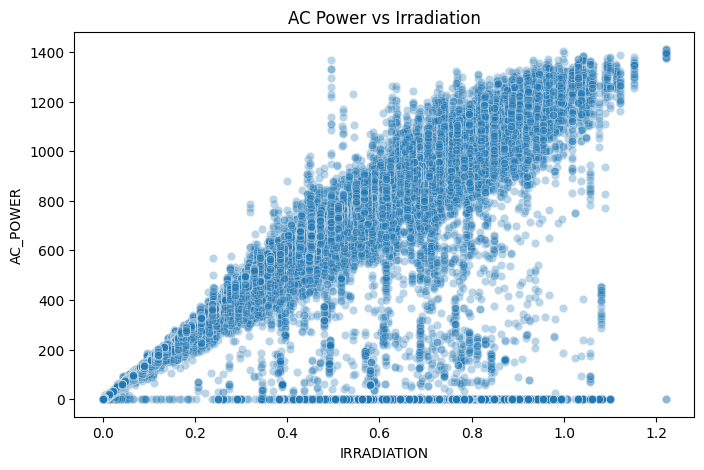

In [150]:
# 3 Power vs Irradiation
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['IRRADIATION'], y=data['AC_POWER'], alpha=0.3)
plt.title("AC Power vs Irradiation")
plt.show()

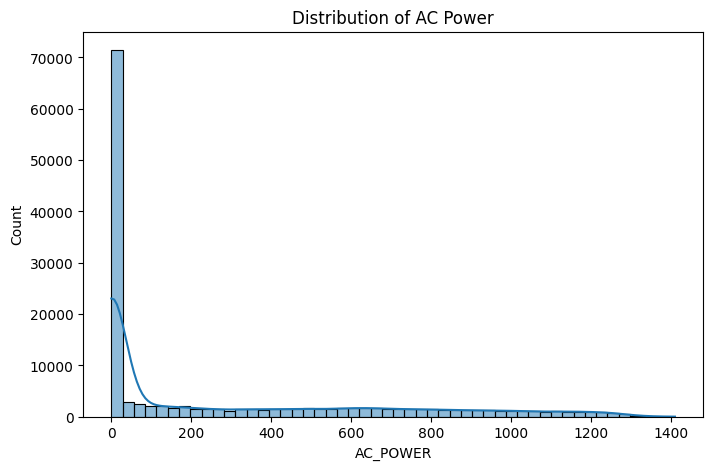

In [151]:
# 4. Distribution of Power
plt.figure(figsize=(8,5))
sns.histplot(data['AC_POWER'], bins=50, kde=True)
plt.title("Distribution of AC Power")
plt.show()

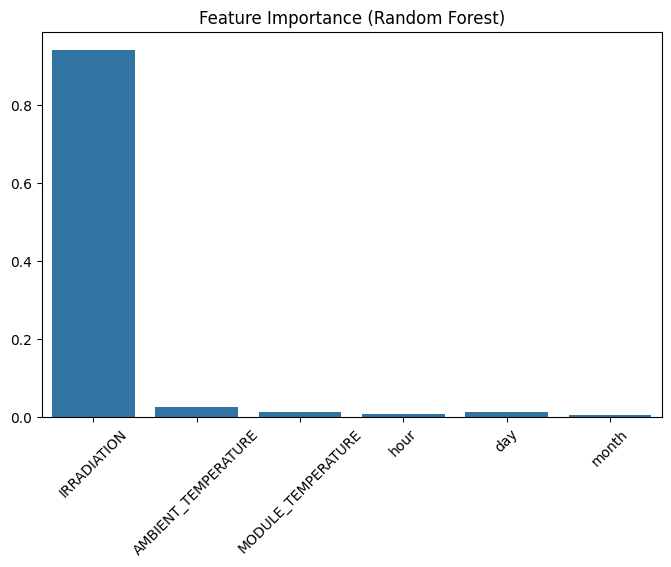

In [152]:
# 5. Feature Importance
rf.fit(X_train, y_train)

importances = rf.feature_importances_

plt.figure(figsize=(8,5))
sns.barplot(x=features, y=importances)
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.show()

# 8 Train-Test Split

In [153]:
# ML MODELS DATA
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LSTM DATA (SEQUENTIAL)
seq_length = 24

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y.iloc[i+seq_length])
    return np.array(Xs), np.array(ys)

# IMPORTANT: convert to DataFrame for indexing
X_seq, y_seq = create_sequences(pd.DataFrame(X), y, seq_length)

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False
)

# 9 Random Forest Model

In [154]:
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train_ml, y_train_ml)
rf_pred = rf.predict(X_test_ml)

In [155]:
rf_pred

array([426.31898388,   0.        ,   0.        , ...,   0.        ,
         2.86903119,   0.        ], shape=(27295,))

# 10 XGBoost Model

In [156]:
xgb = XGBRegressor()
xgb.fit(X_train_ml, y_train_ml)
xgb_pred = xgb.predict(X_test_ml)

In [157]:
xgb_pred

array([ 4.0798456e+02, -2.5805790e-02, -8.0301249e-01, ...,
        5.1420899e-03,  1.7087115e+00,  1.0165009e+00],
      shape=(27295,), dtype=float32)

# 11 Evaluation Function

In [158]:
def evaluate(y_true, pred):
    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2 = r2_score(y_true, pred)
    return mae, rmse, r2

# 12 LSTM Model

In [159]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, X.shape[1])),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

c:\Users\aswan\anaconda3\envs\fake_news\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - loss: 229721.0781 - val_loss: 177913.9688
Epoch 2/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - loss: 208944.3281 - val_loss: 163675.8438
Epoch 3/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 192690.0938 - val_loss: 153116.2188
Epoch 4/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - loss: 180232.4688 - val_loss: 145813.6562
Epoch 5/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - loss: 170776.8125 - val_loss: 141310.9062
Epoch 6/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - loss: 164669.4688 - val_loss: 139203.5938
Epoch 7/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - loss: 148336.6875 - val_loss: 99612.6797
Epoch 8/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - loss: 111594.9062 - val_loss: 87357.3281
Epoch 9/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - loss: 97496.0938 - val_loss: 78232.9375
Epoch 10/10
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - loss: 85768.7344 - val_loss: 70076.1406


# 13 Monte Carlo Dropout

In [160]:
def mc_dropout(model, X, n=50):
    preds = []
    for i in range(n):
        preds.append(model(X, training=True))
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

# 14 Predictions with Uncertainty

In [161]:
mean_pred, std_pred = mc_dropout(model, X_test_lstm)

upper = mean_pred + 2*std_pred
lower = mean_pred - 2*std_pred

# 15 PICP

In [162]:
def PICP(y_true, lower, upper):
    count = ((y_true >= lower.flatten()) & (y_true <= upper.flatten())).sum()
    return count / len(y_true)

picp = PICP(y_test_lstm, lower, upper)
print("PICP:", picp)

PICP: 0.6537559545621107


# 16 Plot Probabilistic Forecast

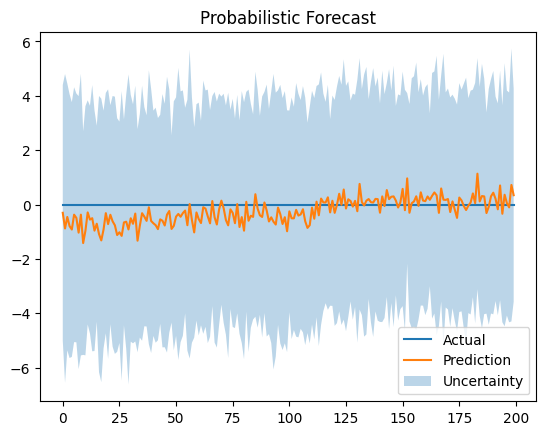

In [163]:
plt.figure()

plt.plot(y_test_lstm[:200], label="Actual")
plt.plot(mean_pred[:200], label="Prediction")

plt.fill_between(
    range(200),
    lower[:200].flatten(),
    upper[:200].flatten(),
    alpha=0.3,
    label="Uncertainty"
)

plt.legend()
plt.title("Probabilistic Forecast")
plt.show()

# 17 CRPS Implementation (for Monte Carlo Dropout)

In [164]:
import numpy as np

def crps_ensemble(y_true, predictions):
    """
    y_true: actual values (N,)
    predictions: ensemble predictions (samples, N)
    """
    n_samples = predictions.shape[0]

    term1 = np.mean(np.abs(predictions - y_true), axis=0)

    term2 = 0
    for i in range(n_samples):
        for j in range(n_samples):
            term2 += np.abs(predictions[i] - predictions[j])

    term2 = term2 / (2 * n_samples**2)

    crps = np.mean(term1 - term2)

    return crps

# 18 Modify MC Dropout Code

In [165]:
def mc_dropout_full(model, X, n=50):
    preds = []
    for i in range(n):
        preds.append(model(X, training=True).numpy().flatten())
    return np.array(preds)

# 19 Compute CRPS

In [166]:
mc_preds = mc_dropout_full(model, X_test_lstm)

crps_value = crps_ensemble(y_test_lstm, mc_preds)

print("CRPS:", crps_value)

CRPS: 102.17981441263477


# 20 Random Forest Tuning

In [167]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor()

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train_ml, y_train_ml)

print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


# 21 XGBoost Tuning

In [168]:
from xgboost import XGBRegressor

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

xgb = XGBRegressor()

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(X_train_ml, y_train_ml)

print("Best XGB Params:", grid_xgb.best_params_)

Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


# 22 LSTM Hyperparameter Tuning

In [169]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, X.shape[1])),
    Dropout(0.4),
    LSTM(64),
    Dropout(0.4),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X_train_lstm, y_train_lstm,
          epochs=20,
          batch_size=32,
          validation_split=0.2)

c:\Users\aswan\anaconda3\envs\fake_news\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 113s 39ms/step - loss: 204191.4062 - val_loss: 147700.7969
Epoch 2/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 89s 33ms/step - loss: 166354.0625 - val_loss: 138792.0156
Epoch 3/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 103s 38ms/step - loss: 158249.1719 - val_loss: 140283.4531
Epoch 4/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 101s 37ms/step - loss: 148013.6094 - val_loss: 82345.0547
Epoch 5/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 98s 36ms/step - loss: 75359.6484 - val_loss: 56222.0938
Epoch 6/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 98s 36ms/step - loss: 48465.1680 - val_loss: 44920.8203
Epoch 7/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 98s 36ms/step - loss: 33531.8359 - val_loss: 40442.4258
Epoch 8/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 102s 37ms/step - loss: 26606.6016 - val_loss: 40701.4141
Epoch 9/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 107s 39ms/step - loss: 23654.3574 - val_loss: 41973.7852
Epoch 10/20
2729/2729 ━━━━━━━━━━━━━━━━━━━━ 111s 41ms/step - loss: 22612.8281 - val_loss: 41848.4453
Epoch 

# 23 Performance Evaluation

In [170]:
rf_mae, rf_rmse, rf_r2 = evaluate(y_test_ml, rf_pred)
xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test_ml, xgb_pred)

print("Random Forest:", rf_mae, rf_rmse, rf_r2)
print("XGBoost:", xgb_mae, xgb_rmse, xgb_r2)

Random Forest: 49.182962759391664 150.4520171379981 0.8438755322403437
XGBoost: 49.876817864526004 149.19927329510267 0.8464646593406866


In [171]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [rf_mae, xgb_mae],
    'RMSE': [rf_rmse, xgb_rmse],
    'R2': [rf_r2, xgb_r2]
})

print(results)

           Model        MAE        RMSE        R2
0  Random Forest  49.182963  150.452017  0.843876
1        XGBoost  49.876818  149.199273  0.846465


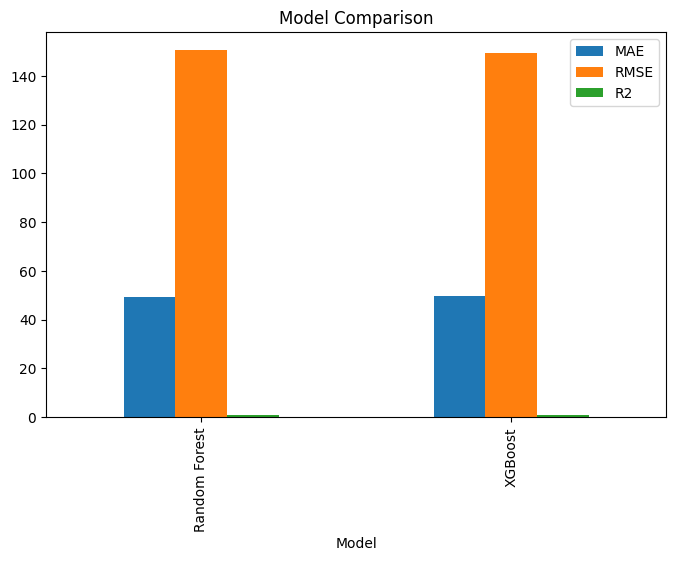

In [172]:
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.show()

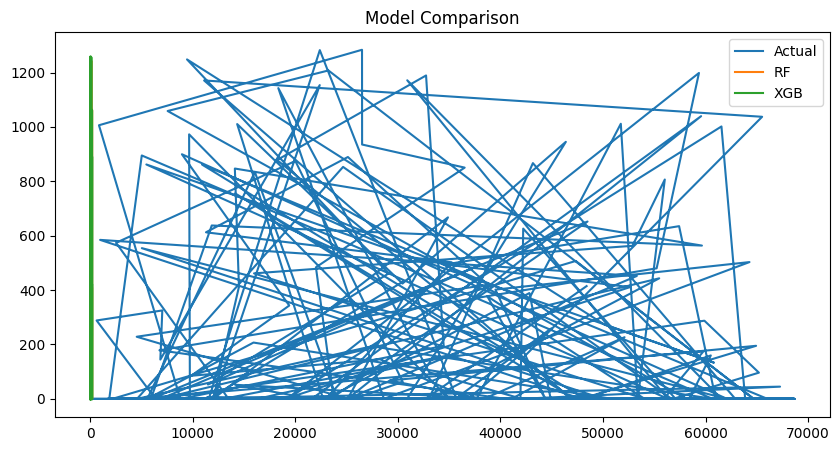

In [180]:
plt.figure(figsize=(10,5))
plt.plot(y_test_ml[:200], label='Actual')
plt.plot(rf_pred[:200], label='RF')
plt.plot(xgb_pred[:200], label='XGB')
plt.legend()
plt.title("Model Comparison")
plt.show()

853/853 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step


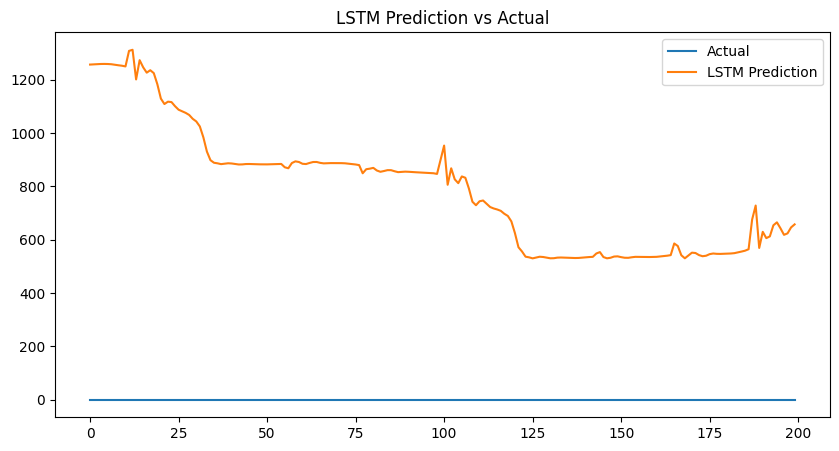

In [179]:
lstm_pred = model.predict(X_test_lstm)
lstm_pred = scaler_y.inverse_transform(lstm_pred.reshape(-1,1)).flatten()
y_test_lstm_actual = scaler_y.inverse_transform(y_test_lstm.reshape(-1,1)).flatten()
plt.figure(figsize=(10,5))
plt.plot(y_test_lstm[:200], label='Actual')
plt.plot(lstm_pred[:200], label='LSTM Prediction')
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()

# 24 Uncertainity

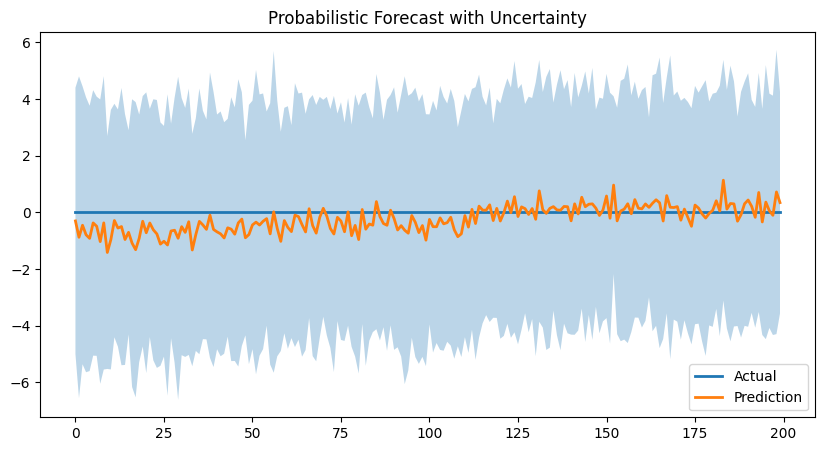

In [174]:
plt.figure(figsize=(10,5))

plt.plot(y_test_lstm[:200], label="Actual", linewidth=2)
plt.plot(mean_pred[:200], label="Prediction", linewidth=2)

plt.fill_between(
    range(200),
    lower[:200].flatten(),
    upper[:200].flatten(),
    alpha=0.3
)

plt.legend()
plt.title("Probabilistic Forecast with Uncertainty")
plt.show()

In [175]:
lstm_mae, lstm_rmse, lstm_r2 = evaluate(y_test_lstm, lstm_pred)

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'MAE': [rf_mae, xgb_mae, lstm_mae],
    'RMSE': [rf_rmse, xgb_rmse, lstm_rmse],
    'R2': [rf_r2, xgb_r2, lstm_r2]
})

print(results)

           Model        MAE        RMSE        R2
0  Random Forest  49.182963  150.452017  0.843876
1        XGBoost  49.876818  149.199273  0.846465
2           LSTM  87.066111  229.255846  0.498103


# 25 Visualizing the Results

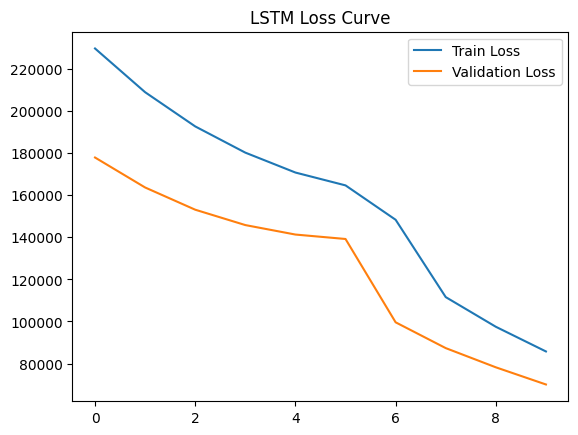

In [181]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Loss Curve")
plt.show()

# 26 Residual Analysis

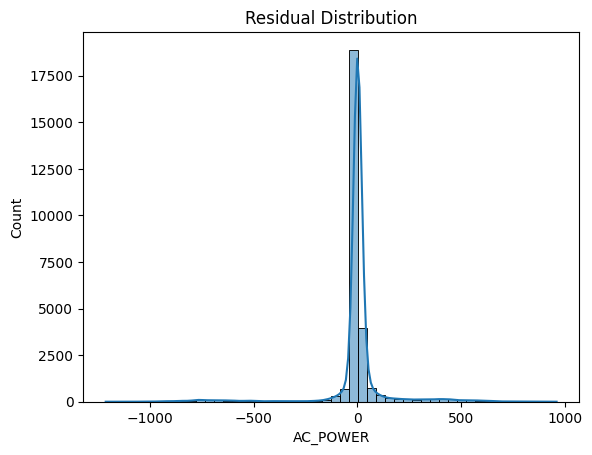

In [184]:
residuals = y_test_ml - rf_pred

sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.show()

# 27 Scater Plot

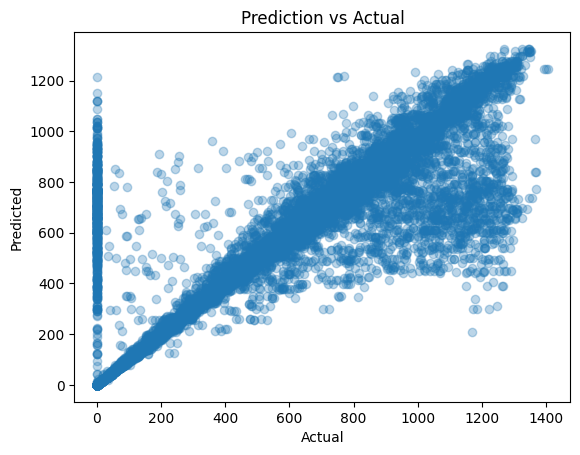

In [185]:
plt.scatter(y_test_ml, rf_pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual")
plt.show()